In [24]:
# ===============================
# Import Required Libraries
# ===============================

import os
import glob
import shutil
import re
import pandas as pd

# Kaggle API for dataset download
from kaggle.api.kaggle_api_extended import KaggleApi

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Sparse matrix handling for combining features
from scipy.sparse import hstack, csr_matrix

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
# ===============================
# Download Dataset from Kaggle
# ===============================

DATASET = "naserabdullahalam/phishing-email-dataset"
TMP_DIR = ".tmp_kaggle_download"

# Authenticate Kaggle API
api = KaggleApi()
api.authenticate()

# Ensure a clean temporary directory
if os.path.exists(TMP_DIR):
    shutil.rmtree(TMP_DIR)
os.makedirs(TMP_DIR, exist_ok=True)

# Download and extract dataset
api.dataset_download_files(DATASET, path=TMP_DIR, unzip=True)

# Locate CSV files
csv_files = [f for f in glob.glob(os.path.join(TMP_DIR, "*.csv"))
             if "CEAS_08" in os.path.basename(f)]

print("CSV files downloaded:", csv_files)

Dataset URL: https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset
CSV files downloaded: ['.tmp_kaggle_download\\CEAS_08.csv']


In [3]:
# Load Data
dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [4]:
# ===============================
# Download Dataset from Kaggle
# ===============================

DATASET = "naserabdullahalam/phishing-email-dataset"
TMP_DIR = ".tmp_kaggle_download"

# Authenticate Kaggle API
api = KaggleApi()
api.authenticate()

# Ensure a clean temporary directory
if os.path.exists(TMP_DIR):
    shutil.rmtree(TMP_DIR)
os.makedirs(TMP_DIR, exist_ok=True)

# Download and extract dataset
api.dataset_download_files(DATASET, path=TMP_DIR, unzip=True)

# Locate CSV files
csv_files = [f for f in glob.glob(os.path.join(TMP_DIR, "*.csv"))
             if "CEAS_08" in os.path.basename(f)]

print("CSV files downloaded:", csv_files)

Dataset URL: https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset
CSV files downloaded: ['.tmp_kaggle_download\\CEAS_08.csv']


In [5]:
# ===============================
# Load Dataset into DataFrame
# ===============================

# Read all CSV files and combine into one DataFrame
dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

# Preview data
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [6]:
# ===============================
# Feature Engineering
# ===============================

# Ensure all text fields are strings
df["subject"] = df["subject"].fillna("").astype(str)
df["body"] = df["body"].fillna("").astype(str)

# Create combined email text (REQUIRED BEFORE FEATURES)
df["email_text"] = df["subject"] + " " + df["body"]

# Basic metadata features
df["subject_length"] = df["subject"].apply(len)
df["body_length"] = df["body"].apply(len)
df["url_count"] = df["urls"]

In [7]:
# ===============================
# Feature Engineering
# ===============================

# Basic metadata features
df["subject_length"] = df["subject"].apply(len)
df["body_length"] = df["body"].apply(len)
df["url_count"] = df["urls"]

# Define phishing-related keywords
phishing_keywords = [
    "urgent","verify","click","login","password",
    "account","bank","security","update","confirm"
]

# Count phishing keywords in email text
df["phishing_keyword_count"] = df["email_text"].apply(
    lambda x: sum(x.count(word) for word in phishing_keywords)
)

# Count uppercase words (often used in spam/phishing emails)
df["uppercase_count"] = df["email_text"].apply(
    lambda x: sum(1 for word in x.split() if word.isupper())
)

# Count numeric characters (common in suspicious links or codes)
df["digit_count"] = df["email_text"].str.count(r"\d")

In [8]:
# ===============================
# Split Dataset into Train & Test Sets
# ===============================

X = df['email_text']
y = df['label']

# Stratified split ensures class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# ===============================
# Convert Text to Numerical Features (TF-IDF)
# ===============================

tfidf = TfidfVectorizer(
    max_features=5000,     # Limit vocabulary size
    ngram_range=(1, 2),    # Include unigrams and bigrams
    stop_words='english'   # Remove common words
)

# Fit on training data only (avoid data leakage)
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using same vectorizer
X_test_tfidf = tfidf.transform(X_test)

In [10]:
# ===============================
# Combine TF-IDF with Metadata Features
# ===============================

meta_features = [
    'subject_length','body_length','url_count',
    'phishing_keyword_count','uppercase_count','digit_count'
]

# Extract corresponding metadata rows
X_train_meta = df.loc[X_train.index, meta_features]
X_test_meta = df.loc[X_test.index, meta_features]

# Convert metadata to sparse format
X_train_meta_sparse = csr_matrix(X_train_meta.values)
X_test_meta_sparse = csr_matrix(X_test_meta.values)

# Combine text features with metadata features
X_train_final = hstack([X_train_tfidf, X_train_meta_sparse])
X_test_final = hstack([X_test_tfidf, X_test_meta_sparse])

In [11]:
# ===============================
# Train Logistic Regression Model
# ===============================

model = LogisticRegression(max_iter=1000, solver='liblinear')

# Train model using combined features
model.fit(X_train_final, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
# ===============================
# Model Prediction & Evaluation
# ===============================

# Generate predictions on test data
y_pred = model.predict(X_test_final)

# Accuracy: overall correctness
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))

# Classification Report: precision, recall, F1-score
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix: detailed prediction breakdown
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.9900

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3462
           1       0.99      0.99      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831


Confusion Matrix:

[[3419   43]
 [  35 4334]]


In [13]:
# ===============================
# Cleanup Temporary Files
# ===============================

# Remove downloaded dataset to avoid storing large files
shutil.rmtree(TMP_DIR)

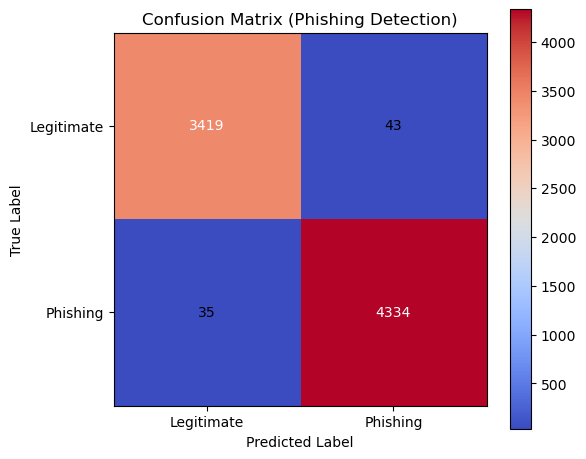

In [21]:
# ===============================
# Confusion Matrix Heatmap
# ===============================

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="coolwarm")

plt.title("Confusion Matrix (Phishing Detection)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

labels = ["Legitimate", "Phishing"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max()/2 else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.colorbar()
plt.grid(False)
plt.tight_layout()

plt.show() 

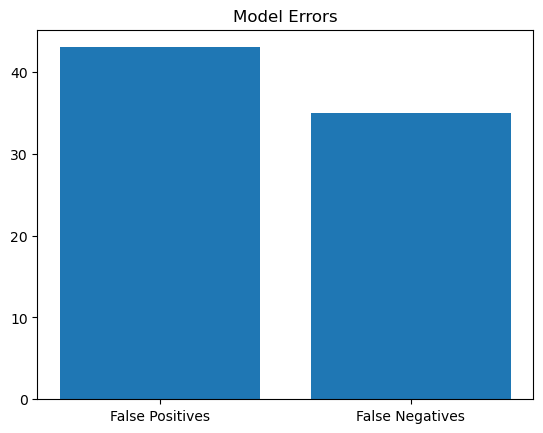

In [26]:
errors = ["False Positives", "False Negatives"]
values = [43, 35]

plt.figure()
plt.bar(errors, values)
plt.title("Model Errors")
plt.show()